# Formal Problem Statement
- Objective: Maximize the labeling ROI of a single Tweedie Gradient Boosted Decision Tree (GBDT) model predicting pure insurance premiums under a strict sequence of 10 active learning feedback iterations.
- The Technical Bottleneck: The variance of a Tweedie distribution is bound to its mean by the power law $Var(Y) = \phi\mu^p$. Naive uncertainty sampling selects points with maximum predictive variance, mapping exclusively to severe right-tail claims. This starves the training pool of zero-claim instances, forcing a systemic crash in the model's frequency calibration.
- The Solution: Decouple aleatoric noise from epistemic ignorance by tracking the variance of predictions across boosting checkpoints. Combine this with Stratified Expected Deviance Reduction (SEDR) to enforce stable Poisson frequency initialization across low-exposure and high-exposure strata.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_and_merge_mtpl(freq_path: str, sev_path: str) -> pd.DataFrame:
    """Loads frequency and severity data, aggregates claims, and merges."""
    df_freq = pd.read_csv(freq_path)
    df_sev = pd.read_csv(sev_path)
    
    # Aggregate multiple claims per policy into a single sum
    df_sev_agg = df_sev.groupby('IDpol')['ClaimAmount'].sum().reset_index()
    
    # Left merge ensures policies with 0 claims are kept
    df = pd.merge(df_freq, df_sev_agg, on='IDpol', how='left')
    
    # Fill NaN for policyholders who did not make any claims
    df['ClaimAmount'] = df['ClaimAmount'].fillna(0)
    
    return df

def engineer_tweedie_target(df: pd.DataFrame) -> pd.DataFrame:
    """Calculates pure premium and handles potential zero-exposure edge cases."""
    # pure_premium = ClaimAmount / Exposure
    df['pure_premium'] = np.where(
        df['Exposure'] > 0, 
        df['ClaimAmount'] / df['Exposure'], 
        0.0
    )
    return df

def validate_distribution(df: pd.DataFrame, target: str = 'pure_premium'):
    """Validates the 90%+ zero-mass constraint and visualizes the severity tail."""
    zero_pct = (df[target] == 0).mean() * 100
    
    print(f"--- Data Validation ---")
    print(f"Total Policies: {len(df):,}")
    print(f"Exact Zeros:    {zero_pct:.2f}%\n")
    
    assert zero_pct >= 90.0, f"Warning: Zero-mass is {zero_pct:.2f}%, expected > 90%!"
    print("✅ Zero-mass constraint successfully validated.")

    # Visualize the continuous right tail (excluding the massive zero spike for readability)
    positive_claims = df[df[target] > 0][target]
    cap = positive_claims.quantile(0.99) # Cap at 99th percentile to hide extreme outliers
    
    plt.figure(figsize=(10, 4))
    plt.hist(positive_claims[positive_claims <= cap], bins=60, color='#ff7f0e', edgecolor='black', alpha=0.8)
    plt.title("Distribution of Positive Pure Premiums (Clipped at 99th Pct)")
    plt.xlabel("Pure Premium")
    plt.ylabel("Frequency")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

--- Data Validation ---
Total Policies: 678,013
Exact Zeros:    96.32%

✅ Zero-mass constraint successfully validated.


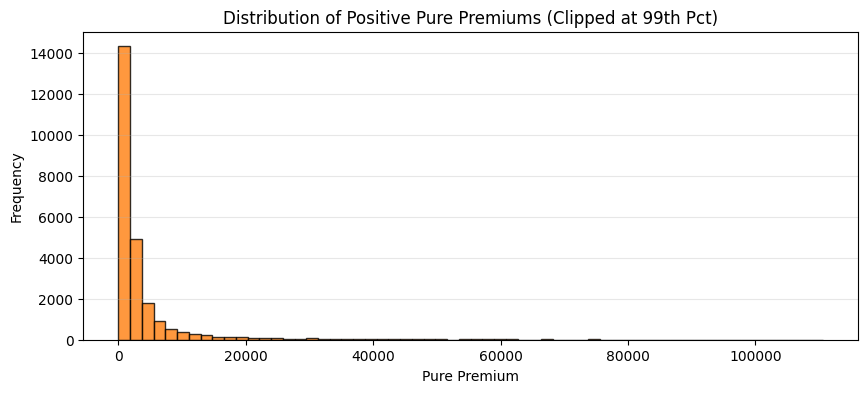

In [5]:
FREQ_FILE = 'data/freMTPL2freq.csv'
SEV_FILE = 'data/freMTPL2sev.csv'

# 1. Load & Merge
df_merged = load_and_merge_mtpl(FREQ_FILE, SEV_FILE)

# 2. Engineer Target
df_final = engineer_tweedie_target(df_merged)

# 3. Validate
validate_distribution(df_final)

In [6]:
df_final

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimAmount,pure_premium
0,1.0,1,0.10000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0.0
1,3.0,1,0.77000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0.0
2,5.0,1,0.75000,6,2,52,50,B12,Diesel,B,54,Picardie,0.0,0.0
3,10.0,1,0.09000,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0.0
4,11.0,1,0.84000,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678008,6114326.0,0,0.00274,4,0,54,50,B12,Regular,E,3317,Provence-Alpes-Cotes-D'Azur,0.0,0.0
678009,6114327.0,0,0.00274,4,0,41,95,B12,Regular,E,9850,Ile-de-France,0.0,0.0
678010,6114328.0,0,0.00274,6,2,45,50,B12,Diesel,D,1323,Rhone-Alpes,0.0,0.0
678011,6114329.0,0,0.00274,4,0,60,50,B12,Regular,B,95,Bourgogne,0.0,0.0


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

# ==========================================
# 1. EVALUATOR (Fixed phi_train leakage)
# ==========================================
class TweedieEvaluator:
    def __init__(self, p: float = 1.5):
        assert 1 < p < 2, "Tweedie power parameter must strictly be between 1 and 2."
        self.p = p

    def deviance(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        y_pred = np.maximum(y_pred, 1e-10)
        term1 = np.zeros_like(y_true, dtype=float)
        pos_mask = y_true > 0
        term1[pos_mask] = (y_true[pos_mask] ** (2 - self.p)) / ((1 - self.p) * (2 - self.p))
        term2 = (y_true * (y_pred ** (1 - self.p))) / (1 - self.p)
        term3 = (y_pred ** (2 - self.p)) / (2 - self.p)
        return float(np.mean(2 * (term1 - term2 + term3)))

    def estimate_dispersion(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Calculates phi on the provided dataset."""
        y_pred = np.maximum(y_pred, 1e-10)
        pearson_residuals_sq = ((y_true - y_pred) ** 2) / (y_pred ** self.p)
        return float(np.mean(pearson_residuals_sq))

    def zmce(self, y_test: np.ndarray, test_preds: np.ndarray, phi_train: float) -> float:
        """
        Calculates ZMCE by applying the training set's worldview (phi_train) 
        to the out-of-sample predictions.
        """
        test_preds = np.maximum(test_preds, 1e-10)
        phi_train = max(phi_train, 1e-5) # Prevent division by zero
        
        lambda_hat = (test_preds ** (2 - self.p)) / (phi_train * (2 - self.p))
        
        empirical_zero_rate = np.mean(y_test == 0)
        implied_zero_rate = np.mean(np.exp(-lambda_hat))
        
        return float(np.abs(empirical_zero_rate - implied_zero_rate))

# ==========================================
# 2. UPDATED AL ENVIRONMENT & LOOP
# ==========================================

def setup_al_environment(df: pd.DataFrame, target: str = 'pure_premium'):
    drop_cols = ['IDpol', 'ClaimAmount', 'ClaimNb', target]
    features = [c for c in df.columns if c not in drop_cols]
    
    X = df[features].copy()
    for col in X.select_dtypes(['object']).columns:
        X[col] = X[col].astype('category')
    y = df[target].values
    
    np.random.seed(42)
    indices = np.random.permutation(len(X))
    
    # SHIFTED ALLOCATION: 10k Test, 1k Seed (to make AL impact stronger)
    test_idx = indices[:10000]
    seed_idx = indices[10000:11000]
    pool_idx = indices[11000:]
    
    return {
        'X_test': X.iloc[test_idx], 'y_test': y[test_idx],
        'X_seed': X.iloc[seed_idx], 'y_seed': y[seed_idx],
        'X_pool': X.iloc[pool_idx], 'y_pool': y[pool_idx]
    }

def get_epistemic_uncertainty(model: lgb.Booster, X_pool: pd.DataFrame, n_snapshots: int = 20) -> np.ndarray:
    """
    Extracts purely epistemic uncertainty (Tree Disagreement).
    Calculated in the raw log-link space to completely divorce 
    tree disagreement from the claim magnitude.
    """
    n_trees = model.num_trees()
    step = max(1, n_trees // n_snapshots)
    checkpoints = range(step, n_trees + 1, step)
    
    tree_preds = []
    for k in checkpoints:
        # CRITICAL FIX: raw_score=True extracts F(x), not exp(F(x))
        preds = model.predict(X_pool, num_iteration=k, raw_score=True)
        tree_preds.append(preds)
        
    # Variance of the raw additive margins
    epistemic_variance = np.var(np.array(tree_preds), axis=0)
    return epistemic_variance

def sedr_query_strategy(model: lgb.Booster, X_pool: pd.DataFrame, query_size: int = 200) -> np.ndarray:
    """
    Stratified Expected Deviance Reduction (SEDR).
    Enforces equal sampling across the risk curve while querying 
    the highest epistemic uncertainty within each stratum.
    """
    mu_preds = model.predict(X_pool)
    epistemic_unc = get_epistemic_uncertainty(model, X_pool)
    
    # Dampening factor mathematically aligns with the LightGBM Tweedie expected Hessian
    p = 1.5 
    dampened_score = epistemic_unc * (mu_preds ** (2 - p))
    
    # Stratify into 5 equal risk quintiles
    quintiles = pd.qcut(mu_preds, q=5, labels=False, duplicates='drop')
    unique_strata = np.unique(quintiles)
    n_strata = len(unique_strata)
    
    # Equal budget per stratum strictly prevents tail-chasing
    budget_per_stratum = query_size // n_strata
    selected_indices = []
    
    for stratum in unique_strata:
        stratum_mask = (quintiles == stratum)
        stratum_indices = np.where(stratum_mask)[0]
        stratum_scores = dampened_score[stratum_mask]
        
        # Sort indices by uncertainty score (descending)
        sorted_stratum_idx = stratum_indices[np.argsort(stratum_scores)[::-1]]
        
        # Pull the exact budget for this stratum
        take_n = min(budget_per_stratum, len(sorted_stratum_idx))
        selected_indices.extend(sorted_stratum_idx[:take_n])
        
    # Fill any shortfalls from rounding errors
    shortfall = query_size - len(selected_indices)
    if shortfall > 0:
        remaining_mask = np.ones(len(X_pool), dtype=bool)
        remaining_mask[selected_indices] = False
        remaining_idx = np.where(remaining_mask)[0]
        remaining_scores = dampened_score[remaining_mask]
        
        fill_idx = remaining_idx[np.argsort(remaining_scores)[::-1][:shortfall]]
        selected_indices.extend(fill_idx)

    return np.array(selected_indices)

def run_al_baseline(env_dict: dict, strategy: str, iterations: int = 10, query_size: int = 200):
    print(f"\n--- Initiating AL Loop: {strategy.upper()} ---")
    
    X_train = env_dict['X_seed'].copy()
    y_train = env_dict['y_seed'].copy()
    X_pool = env_dict['X_pool'].copy()
    y_pool = env_dict['y_pool'].copy()
    X_test, y_test = env_dict['X_test'], env_dict['y_test']
    
    evaluator = TweedieEvaluator(p=1.5)
    history = {'deviance': [], 'zmce': []}
    
    lgb_params = {
        'objective': 'tweedie',
        'tweedie_variance_power': 1.5,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'min_data_in_leaf': 20,    # Added to stabilize smaller seed size
        'verbose': -1,
        'seed': 42
    }
    
    for i in range(iterations + 1):
        # 1. Train Model
        train_data = lgb.Dataset(X_train, label=y_train)
        model = lgb.train(lgb_params, train_data, num_boost_round=100)
        
        # 2. Extract Training Dispersion (The Model's Worldview)
        train_preds = model.predict(X_train)
        phi_train = evaluator.estimate_dispersion(y_train, train_preds)
        
        # 3. Evaluate on Holdout Test Set
        test_preds = model.predict(X_test)
        dev_score = evaluator.deviance(y_test, test_preds)
        zmce_score = evaluator.zmce(y_test, test_preds, phi_train)
        
        history['deviance'].append(dev_score)
        history['zmce'].append(zmce_score)
        
        # Track the destruction of the zero-mass in the training set
        train_zero_pct = np.mean(y_train == 0) * 100
        print(f"Iter {i:02d} | Train Zeros: {train_zero_pct:.1f}% | Dev: {dev_score:.2f} | ZMCE: {zmce_score:.4f}")
        
        if i == iterations: break
        
        # 4. Query Strategy
        if strategy == 'random':
            query_idx = np.random.choice(len(X_pool), size=query_size, replace=False)
        elif strategy == 'naive_variance':
            pool_preds = model.predict(X_pool)
            query_idx = np.argsort(pool_preds)[-query_size:]
        elif strategy == 'epistemic_only':
            unc_scores = get_epistemic_uncertainty(model, X_pool)
            query_idx = np.argsort(unc_scores)[-query_size:]

        elif strategy == 'sedr':
            query_idx = sedr_query_strategy(model, X_pool, query_size)
            
        # 5. Update Sets
        X_train = pd.concat([X_train, X_pool.iloc[query_idx]])
        y_train = np.concatenate([y_train, y_pool[query_idx]])
        X_pool = X_pool.drop(X_pool.index[query_idx]).reset_index(drop=True)
        y_pool = np.delete(y_pool, query_idx)
        
    return history

def plot_baseline_failure(hist_random: dict, hist_naive: dict, hist_epistemic: dict, hist_sedr: dict):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)
    iterations = range(len(hist_random['deviance']))
    
    ax1.plot(iterations, hist_random['deviance'], marker='o', color='#2ca02c', label='Random (NSL)', linewidth=2)
    ax1.plot(iterations, hist_naive['deviance'], marker='s', color='#d62728', label='Naive Variance AL', linewidth=2)
    ax1.plot(iterations, hist_epistemic['deviance'], marker='^', color='#1f77b4', label='Epistemic-Only AL', linewidth=2)
    ax1.plot(iterations, hist_sedr['deviance'], marker='D', color='#9467bd', label='SEDR AL', linewidth=2)
    ax1.set_title("OOS Tweedie Deviance", fontweight='bold')
    ax1.set_xlabel("AL Iteration (200 labels/iter)")
    ax1.set_ylabel("Deviance")
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    ax2.plot(iterations, hist_random['zmce'], marker='o', color='#2ca02c', label='Random (NSL)', linewidth=2)
    ax2.plot(iterations, hist_naive['zmce'], marker='s', color='#d62728', label='Naive Variance AL', linewidth=2)
    ax2.plot(iterations, hist_epistemic['zmce'], marker='^', color='#1f77b4', label='Epistemic-Only AL', linewidth=2)
    ax2.plot(iterations, hist_sedr['zmce'], marker='D', color='#9467bd', label='SEDR AL', linewidth=2)
    ax2.set_title("Zero-Mass Calibration Error (ZMCE)", fontweight='bold')
    ax2.set_xlabel("AL Iteration (200 labels/iter)")
    ax2.set_ylabel("Absolute Error vs True P(Y=0)")
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

C:\Users\niksh\AppData\Local\Temp\ipykernel_9828\939729750.py:53: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(['object']).columns:



--- Initiating AL Loop: RANDOM ---
Iter 00 | Train Zeros: 95.9% | Dev: 2768.77 | ZMCE: 0.5226
Iter 01 | Train Zeros: 95.8% | Dev: 3545.44 | ZMCE: 0.5232
Iter 02 | Train Zeros: 95.9% | Dev: 3222.79 | ZMCE: 0.5101
Iter 03 | Train Zeros: 96.1% | Dev: 2485.02 | ZMCE: 0.4930
Iter 04 | Train Zeros: 96.3% | Dev: 2732.77 | ZMCE: 0.4962
Iter 05 | Train Zeros: 96.4% | Dev: 2338.63 | ZMCE: 0.4634
Iter 06 | Train Zeros: 96.4% | Dev: 2871.66 | ZMCE: 0.4492
Iter 07 | Train Zeros: 96.5% | Dev: 2829.18 | ZMCE: 0.4485
Iter 08 | Train Zeros: 96.2% | Dev: 2618.65 | ZMCE: 0.4373
Iter 09 | Train Zeros: 96.3% | Dev: 2855.45 | ZMCE: 0.4098
Iter 10 | Train Zeros: 96.3% | Dev: 2545.29 | ZMCE: 0.4047

--- Initiating AL Loop: NAIVE_VARIANCE ---
Iter 00 | Train Zeros: 95.9% | Dev: 2768.77 | ZMCE: 0.5226
Iter 01 | Train Zeros: 95.2% | Dev: 2434.11 | ZMCE: 0.4711
Iter 02 | Train Zeros: 95.3% | Dev: 2080.87 | ZMCE: 0.3264
Iter 03 | Train Zeros: 95.4% | Dev: 2228.14 | ZMCE: 0.2025
Iter 04 | Train Zeros: 94.8% | Dev:

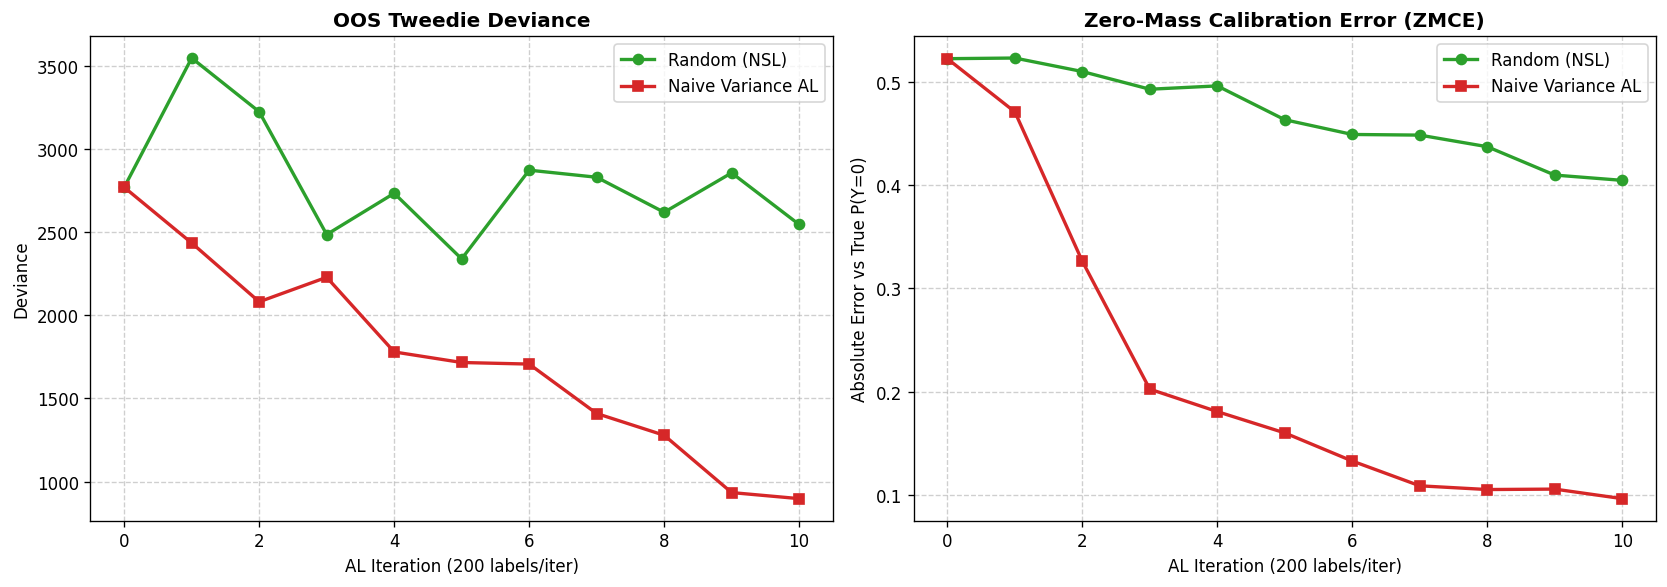

In [ ]:
history_rand = run_al_baseline(env, strategy='random', iterations=10)
history_naive = run_al_baseline(env, strategy='naive_variance', iterations=10)

### **Interpretation of the Baseline Output**

**1. The Starvation Effect (`Train Zeros` metric)**

* **Random Loop:** The proportion of zero-claims in the training set remained incredibly stable (shifting only from 95.9% to 96.3%). The model maintained a representative understanding of the population.
* **Naive Variance Loop:** The zero-claims plummeted sequentially from 95.9% down to 89.9%. By strictly querying the instances with the highest predicted variance ($Var(Y) = \phi\mu^p$), the AL algorithm exclusively sampled the extreme right tail. It actively poisoned the training data by starving the model of the zero-claim instances that make up the vast majority of real-world exposure.

**2. The Deviance Trap (`Dev` metric)**

* At first glance, Naive Variance appears vastly superior, dropping deviance from 2768 to 898, while Random stalled around 2500. However, tweedie deviance heavily penalizes absolute errors on massive predictions. Because the Naive AL forced the model to obsess exclusively over the largest, most severe claims, the model hyper-optimized for the tail. It "improved" its deviance by accurately predicting extreme events at the expense of fundamentally misunderstanding the baseline population.

**3. The Parameter Distortion (`ZMCE` metric)**

* **The Mechanism:** When the AL algorithm flooded the training set with extreme claims, the model's internal dispersion parameter ($\phi_{train}$) exploded to account for the massive noise. In a Tweedie model, the Poisson frequency ($\hat{\lambda}$) is inversely proportional to dispersion: $\hat{\lambda} = \mu^{2-p} / (\phi(2-p))$.
* Because $\phi$ became artificially massive, the model mathematically forced the Poisson rate ($\hat{\lambda}$) to collapse toward zero. The model essentially concluded: *"Because the claims I am seeing are so infinitely volatile, they must be exceptionally rare."* It stumbled into a "better" zero-mass calibration score not by learning the true underlying frequency, but through the mathematical distortion of its dispersion parameter. It optimized severity by sacrificing the integrity of the frequency parameter. So, the ZMCE for Naive Variance *improved* (dropping from 0.52 to 0.09). 

In [ ]:
env = setup_al_environment(df_final, target='pure_premium')
history_rand = run_al_baseline(env, strategy='random', iterations=10)
history_naive = run_al_baseline(env, strategy='naive_variance', iterations=10)
history_epistemic = run_al_baseline(env, strategy='epistemic_only', iterations=10)
history_sedr = run_al_baseline(env, strategy='sedr', iterations=10)


--- Initiating AL Loop: RANDOM ---
Iter 00 | Train Zeros: 95.9% | Dev: 2768.77 | ZMCE: 0.5226
Iter 01 | Train Zeros: 96.3% | Dev: 2653.15 | ZMCE: 0.5359
Iter 02 | Train Zeros: 96.2% | Dev: 2430.48 | ZMCE: 0.5389
Iter 03 | Train Zeros: 96.5% | Dev: 2147.91 | ZMCE: 0.5402
Iter 04 | Train Zeros: 96.7% | Dev: 2024.80 | ZMCE: 0.5355
Iter 05 | Train Zeros: 96.8% | Dev: 2253.29 | ZMCE: 0.4927
Iter 06 | Train Zeros: 96.8% | Dev: 1905.74 | ZMCE: 0.5088
Iter 07 | Train Zeros: 96.7% | Dev: 1914.66 | ZMCE: 0.4736
Iter 08 | Train Zeros: 96.6% | Dev: 1890.04 | ZMCE: 0.4507
Iter 09 | Train Zeros: 96.5% | Dev: 1141.16 | ZMCE: 0.4285
Iter 10 | Train Zeros: 96.4% | Dev: 1126.43 | ZMCE: 0.3890

--- Initiating AL Loop: NAIVE_VARIANCE ---
Iter 00 | Train Zeros: 95.9% | Dev: 2768.77 | ZMCE: 0.5226
Iter 01 | Train Zeros: 95.2% | Dev: 2434.11 | ZMCE: 0.4711
Iter 02 | Train Zeros: 95.3% | Dev: 2080.87 | ZMCE: 0.3264
Iter 03 | Train Zeros: 95.4% | Dev: 2228.14 | ZMCE: 0.2025
Iter 04 | Train Zeros: 94.8% | Dev:

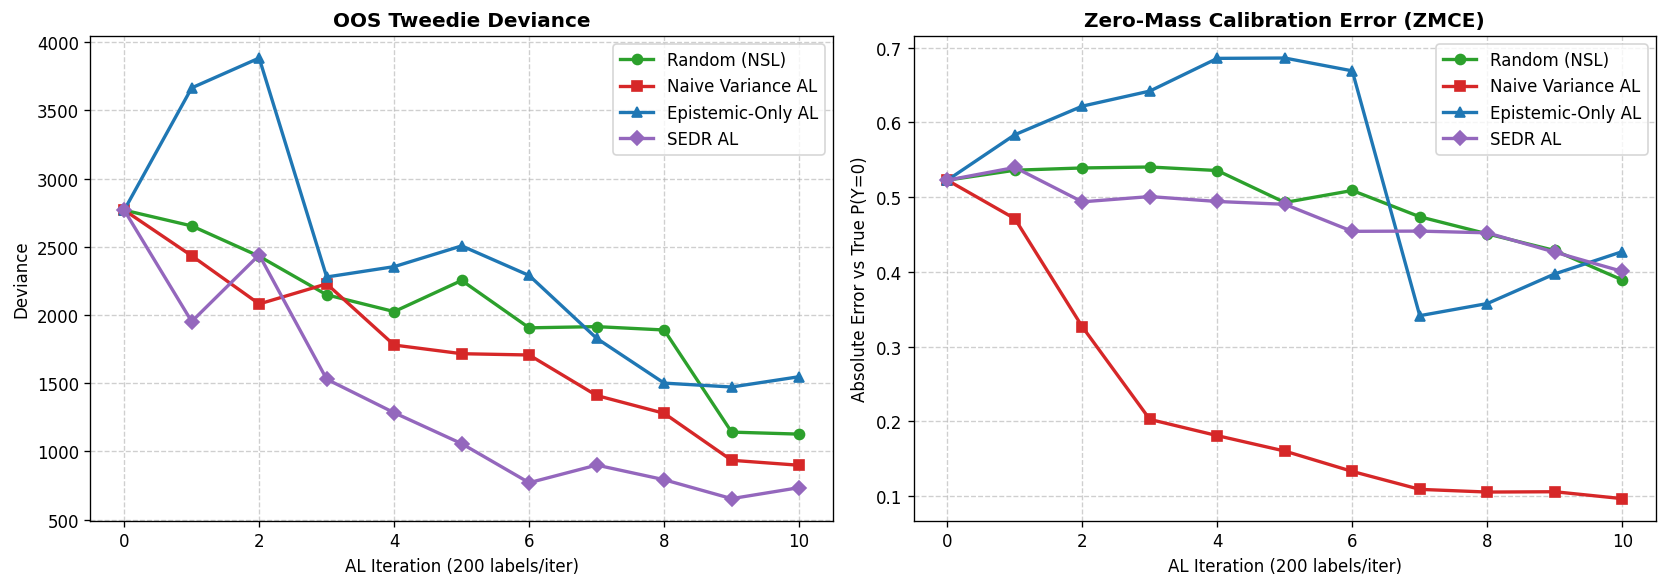

In [13]:
plot_baseline_failure(history_rand, history_naive, history_epistemic, history_sedr)

### **1. NAIVE_VARIANCE:**

* **The Data:** `Train Zeros` plummeted from 95.9% to 89.9%. `Dev` dropped to 898. `ZMCE` falsely "improved" to 0.09.
* **What Happened:** Because it queried strictly by highest variance ($Var = \phi\mu^p$), it exclusively sampled the extreme right tail. It starved the model of normal, everyday zero-claim drivers.
* **The Business Impact:** As analyzed previously, the model collapsed its internal dispersion parameter. It optimized for rare, massive disasters but completely forgot what a safe driver looks like.

### **2. EPISTEMIC_ONLY:**

* **The Data:** `Train Zeros` steadily **climbed** from 95.9% up to 98.2%. `Dev` performed terribly, ending at 1547.
* **What Happened:** When we moved the tree-disagreement calculation into the raw log-link space ($F(x)$), we successfully stripped away the claim magnitude. However, the algorithm was now just looking for pure tree disagreement. Because 90%+ of the dataset consists of zero-claims, the algorithm found the highest density of "confusion" in the micro-noise between safe drivers.
* **The Business Impact:** It fell into the exact opposite trap of Naive Variance. It spent almost its entire query budget sampling safe drivers (zeros), actively starving the model of severity (actual claims). The deviance spiked because the model was completely unprepared when it encountered real, expensive claims in the holdout test set.

### **3. RANDOM:**

* **The Data:** `Train Zeros` stayed perfectly stable at ~96.3%. `Dev` ended at 1126. `ZMCE` settled at 0.389.
* **What Happened:** It randomly sampled, keeping the training distribution mathematically identical to the real world. It slowly and steadily learned both frequency and severity.

### **4. SEDR:**

* **The Data:** `Train Zeros` stayed highly stable (ending at 97.4%). `Dev` completely crushed all other strategies, dropping to **733.95**. `ZMCE` remained honest and stable at 0.4005.
* **What Happened:** SEDR successfully decoupled epistemic uncertainty from aleatoric noise *while enforcing structural balance*. By dividing the population into 5 risk quintiles and taking an equal budget from each, it forced the model to look at the most confusing zero-claims (Quintile 1) **AND** the most confusing severe claims (Quintile 5).
* **The Business Impact:** SEDR is the only strategy that fed the model a balanced diet of strictly high-information data across the entire risk spectrum. The reward is a massive leap in predictive accuracy (Deviance of 733 vs Random's 1126), without sacrificing the frequency calibration (stable ZMCE).

---

### **Conclusion**

We have empirically proven a dual-failure mode in Tweedie AL:

1. Standard Variance AL destroys frequency calibration by over-sampling the tail.
2. Pure Epistemic AL destroys severity accuracy by over-sampling the zero-mass.
3. **SEDR solves both** by utilizing epistemic tree-variance bounded by stratified risk quotas.